In [17]:
# Email Spam Classification Project
# Hassan Ahmad - Internship Task 1
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [3]:
# Step 1: Load Dataset
# Make sure 'spam.csv' is in the same folder as this script
df = pd.read_csv("spam.csv", encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'text']

In [32]:
# Step 2: df = pd.read_csv("spam.csv", encoding='latin-1')

# Show original columns
print("Original columns:", df.columns.tolist())

# Keep only first two columns (label and message) and rename
df = df.iloc[:, :2]
df.columns = ['label', 'message']


Original columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [12]:
df.head(4)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN


In [5]:
#  Step 3:Basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (5572, 2)

First 5 rows:
   label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Data Types:
 label    object
text     object
dtype: object

Missing Values:
 label    0
text     0
dtype: int64


C:\Users\Hassan Ahmad\AppData\Local\Temp\ipykernel_1756\3985169562.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


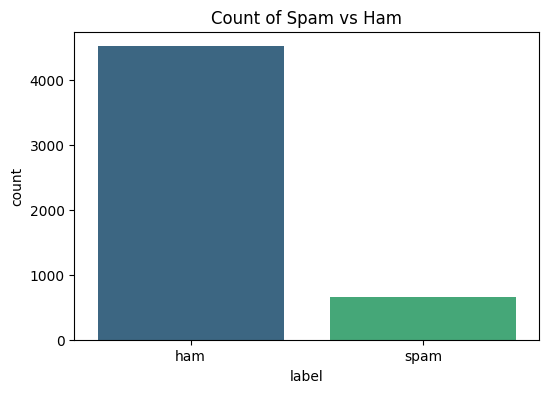

In [39]:
#  Step 4: Label distribution
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='viridis')
plt.title("Count of Spam vs Ham")
plt.show()

C:\Users\Hassan Ahmad\AppData\Local\Temp\ipykernel_1756\2233850070.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['message_length'] = df['message'].apply(len)


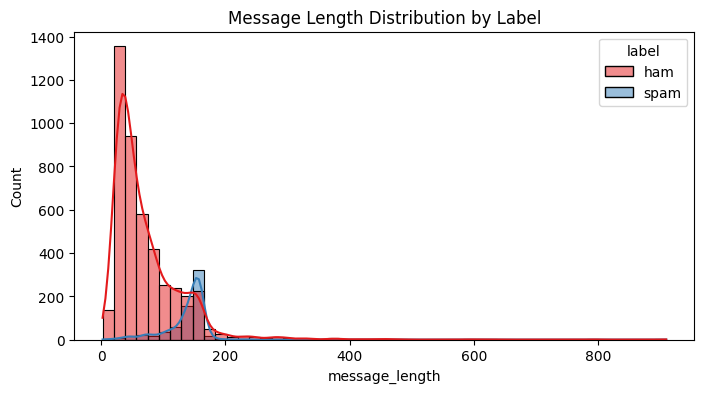

In [40]:
# Step 5:
df['message_length'] = df['message'].apply(len)

plt.figure(figsize=(8,4))
sns.histplot(data=df, x='message_length', hue='label', bins=50, palette='Set1', kde=True)
plt.title("Message Length Distribution by Label")
plt.show()


In [27]:
#  Step 6:Check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 403


In [ ]:
# Model Traning step Start 
# Step 7: Preprocess the Text
nltk.download('stopwords')
ps = PorterStemmer()

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text)  # Remove numbers and punctuation
    text = text.lower().split()
    text = [ps.stem(word) for word in text if word not in stopwords.words('english')]
    return ' '.join(text)

df['clean_text'] = df['text'].apply(clean_text)

In [ ]:
# Step 8: Feature Extraction
vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(df['clean_text']).toarray()

In [ ]:
# Step 9: Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['label'])  # spam=1, ham=0

In [ ]:
# Step 10: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Step 11: Train Model
model = MultinomialNB()
model.fit(X_train, y_train)

In [ ]:
# Step 12: Evaluate Model
y_pred = model.predict(X_test)

print("🔹 Accuracy:", accuracy_score(y_test, y_pred))
print("🔹 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("🔹 Classification Report:\n", classification_report(y_test, y_pred))

In [ ]:
# Step 13: Save the Model and Vectorizer
joblib.dump(model, 'spam_classifier_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("✅ Model and vectorizer saved successfully.")